# 15 — Is "more vimentin in milder lesions" real, or technical?

Notebooks 11–12: astrocytes inside lesions have more αSMA/vimentin signal in milder or resolving disease (MILD vs
SEVERE chronic, MONOPHASIC vs REMISSION1, chronic vs RR at first peak, recovery vs peak), and low lesion vimentin
is the strongest correlate of chronic severity (ρ = −0.80). Here every technical explanation we can think of gets
its own test:

| possible artefact | test |
|---|---|
| staining / imaging batch | only images that hold both groups, compared within image, raw intensities; per image and per run |
| piece brightness, focus, thickness | within-piece contrast; same contrast in DAPI, 18S, ATP1A1; piece sharpness |
| stain weaker overall | **internal calibrator**: αSMA in vascular smooth muscle cells (VSMC) should not differ |
| vessel αSMA leaking into astrocytes | astrocytes > 20 µm from any vessel cell |
| lesions in different places | white matter only; matched distance to tissue edge |
| different lesion composition | within the same lesion state; reactive astrocytes only |
| signal from other cells | lesion neurons and oligodendrocytes as negative controls |

The effect is reported per contrast as a per-animal difference ("milder − more severe"); positive = more vimentin in
the milder / resolving group.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/15_vimentin_robustness.ipynb"
OUT = ROOT / "results" / "15_vimentin_robustness"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
PX = 0.2125

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "Anno_L1_curated", "Anno_L2",
             "x_centroid", "y_centroid"]].copy()
a.file.close()
obs["stage"] = obs.stage.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet"))
clin = pd.read_csv(ROOT / "data" / "clinical" / "animal_course_metrics.csv", index_col=0)

CH = data.CHANNELS
cols = ["section_id", "segmentation_method", "edge_um", "centroid_x_px", "centroid_y_px", "smavim_terr_mean"]
cols += [f"{c}_cell_mean" for c in CH] + [f"{c}_scale" for c in CH] + [f"{c}_bg_local" for c in CH]
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet", columns=cols)
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].join(
    obs[["sample_name", "meta_sample_id", "stage", "arm", "Anno_L1_curated", "Anno_L2", "lesion_state",
         "region_class", "x_centroid", "y_centroid"]], how="inner")
fa["les"] = fa.lesion_state.str.startswith("S")
fa["non"] = fa.lesion_state == "no lesion"
for c in CH:  # raw (not normalised) cell mean, for same-image comparisons
    fa[f"{c}_raw"] = fa[f"{c}_cell_mean"] * fa[f"{c}_scale"] + fa[f"{c}_bg_local"]


def zimg(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


for c in CH:
    fa[f"{c}_z"] = zimg(fa[f"{c}_cell_mean"], fa.section_id)

# distance to nearest vessel cell (endothelial / VSMC) in the same piece
vd = pd.Series(np.inf, index=fa.index)
ves = obs.Anno_L1_curated.isin(["Endothelial", "VSMC"])
for pc, g in fa.groupby("meta_sample_id", observed=True):
    v = obs[(obs.meta_sample_id == pc) & ves]
    if len(v):
        vd[g.index] = cKDTree(v[["x_centroid", "y_centroid"]].to_numpy()).query(g[["x_centroid", "y_centroid"]].to_numpy())[0]
fa["vessel_um"] = vd
print(len(fa), "cells")

1323517 cells


In [3]:
CONTRASTS = {  # name: (milder / resolving mask on animals, more severe / active mask)
    "MILD16 vs SEVERE16": (lambda a: a.stage == "MILD16", lambda a: a.stage == "SEVERE16"),
    "MILD30 vs SEVERE30": (lambda a: a.stage == "MILD30", lambda a: a.stage == "SEVERE30"),
    "MONOPHASIC vs REMISSION1": (lambda a: a.stage == "MONOPHASIC", lambda a: a.stage == "REMISSION1"),
    "chronic vs RR PEAK1": (lambda a: (a.stage == "PEAK1") & (a.arm == "chronic"),
                            lambda a: (a.stage == "PEAK1") & (a.arm == "RR")),
}
animals = fa.groupby("sample_name", observed=True).agg(stage=("stage", "first"), arm=("arm", "first"),
                                                       run=("section_id", lambda s: s.iloc[0].split("_")[0]))


def per_animal(cells, value, min_n=20):
    g = cells.groupby("sample_name", observed=True)[value]
    return g.median().where(g.count() >= min_n)


def effect(series):
    """per contrast: median(milder) - median(severe), n, Mann-Whitney p."""
    out = {}
    for name, (fm, fs) in CONTRASTS.items():
        a_, b_ = series.reindex(animals.index[fm(animals)]).dropna(), series.reindex(animals.index[fs(animals)]).dropna()
        out[name] = (a_.median() - b_.median() if len(a_) and len(b_) else np.nan, len(a_), len(b_),
                     mannwhitneyu(a_, b_).pvalue if len(a_) >= 2 and len(b_) >= 2 else np.nan)
    return out


AST = fa.Anno_L1_curated == "Astrocyte"
tests = {}


def add(name, series):
    tests[name] = effect(series)


# baseline (notebook 11 definition)
add("baseline: lesion astrocytes, vimentin z", per_animal(fa[AST & fa.les], "smavim_z"))
# within-piece contrast
lw = per_animal(fa[AST & fa.les], "smavim_z") - per_animal(fa[AST & fa.non], "smavim_z")
add("within animal: lesion − non-lesion astrocytes", lw)
# control channels, same within-animal contrast (should be ~0 / not follow vimentin)
for c in ["dapi", "r18s", "bnd"]:
    add(f"control channel {plotting.CHANNEL_LABELS[c]}: lesion − non-lesion astrocytes",
        per_animal(fa[AST & fa.les], f"{c}_z") - per_animal(fa[AST & fa.non], f"{c}_z"))
# away from vessels
far = fa.vessel_um > 20
add("astrocytes > 20 µm from any vessel cell", per_animal(fa[AST & fa.les & far], "smavim_z"))
# white matter only, not near the tissue edge (pia)
deep = (fa.region_class == "WM") & (fa.edge_um > 50)
add("white matter, > 50 µm from tissue edge", per_animal(fa[AST & fa.les & deep], "smavim_z"))
# reactive astrocytes only
add("reactive astrocytes (Reactive_AST) only", per_animal(fa[AST & fa.les & (fa.Anno_L2 == "Reactive_AST")], "smavim_z"))
# within lesion state
for s in sorted(fa.lesion_state[fa.les].unique()):
    add(f"within state {s.split(':')[0]}", per_animal(fa[AST & (fa.lesion_state == s)], "smavim_z", min_n=10))
# negative-control cell types
for t in ["Neuron", "Oligodendrocyte"]:
    add(f"negative control: lesion {t.lower()}s", per_animal(fa[(fa.Anno_L1_curated == t) & fa.les], "smavim_z"))
# internal calibrator: VSMC αSMA (should NOT differ if staining is equal)
add("CALIBRATOR: VSMC αSMA/Vim (all VSMC)", per_animal(fa[fa.Anno_L1_curated == "VSMC"], "smavim_z", min_n=10))

rows = []
for tname, d in tests.items():
    for cname, (diff, na, nb, p) in d.items():
        rows.append(dict(test=tname, contrast=cname, diff=diff, n_milder=na, n_severe=nb, p=p))
res = pd.DataFrame(rows)
res.to_csv(OUT / "robustness_tests.csv", index=False)
res.pivot(index="test", columns="contrast", values="diff").reindex(list(tests)).round(2)

contrast,MILD16 vs SEVERE16,MILD30 vs SEVERE30,MONOPHASIC vs REMISSION1,chronic vs RR PEAK1
test,,,,
"baseline: lesion astrocytes, vimentin z",1.05,0.95,3.34,1.03
within animal: lesion − non-lesion astrocytes,1.10,1.09,3.31,0.40
control channel DAPI: lesion − non-lesion astrocytes,-0.18,-0.21,0.00,-0.01
control channel 18S rRNA: lesion − non-lesion astrocytes,0.35,0.13,0.15,-0.17
control channel ATP1A1/CD45/E-Cad: lesion − non-lesion astrocytes,0.19,-0.35,0.60,-0.12
astrocytes > 20 µm from any vessel cell,0.98,0.73,3.07,1.04
"white matter, > 50 µm from tissue edge",2.36,1.24,2.43,1.61
reactive astrocytes (Reactive_AST) only,1.17,1.07,3.30,0.94
within state S0,0.56,0.62,1.67,0.66


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/15_vimentin_robustness/robustness_forest.png')

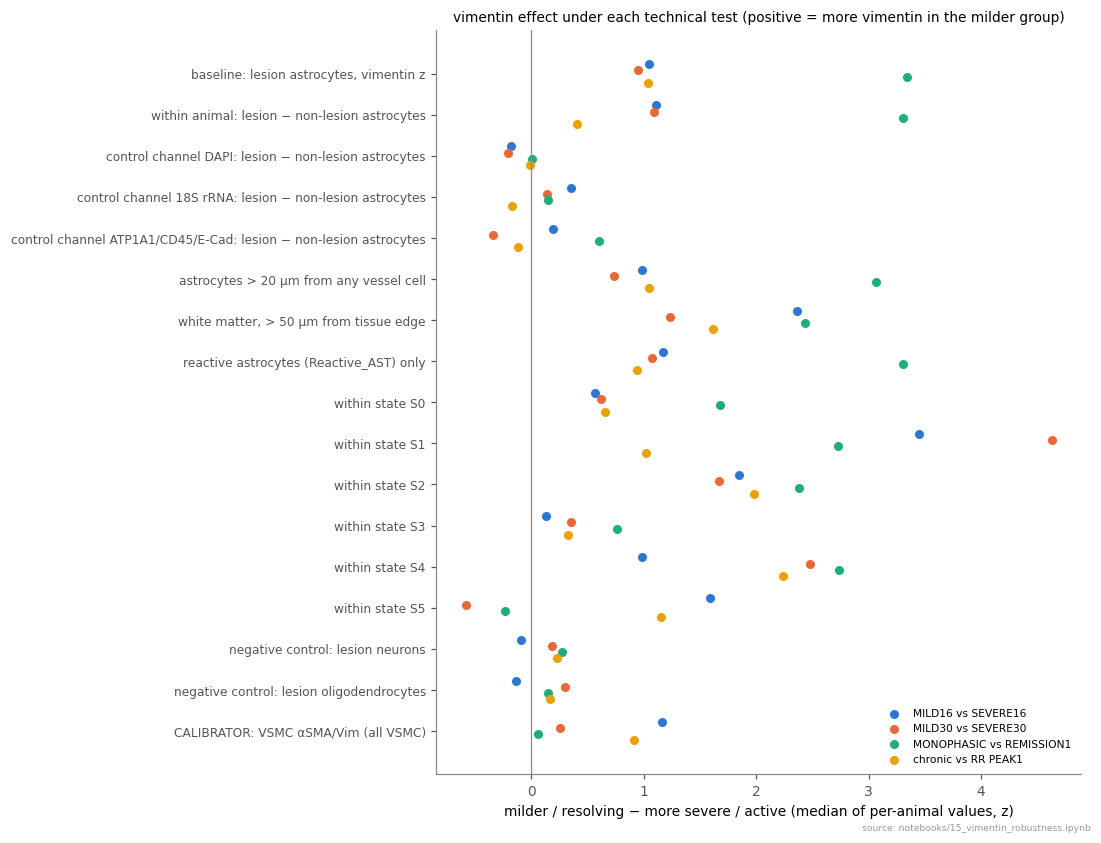

In [4]:
piv = res.pivot(index="test", columns="contrast", values="diff").reindex(list(tests))
fig, ax = plt.subplots(figsize=(10, 0.36 * len(piv) + 1.5))
for j, c in enumerate(piv.columns):
    ax.scatter(piv[c], np.arange(len(piv)) + (j - 1.5) * 0.15, s=24, color=COL[j], label=c)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(range(len(piv)), piv.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("milder / resolving − more severe / active (median of per-animal values, z)")
ax.legend(fontsize=7, loc="lower right")
ax.set_title("vimentin effect under each technical test (positive = more vimentin in the milder group)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "robustness_forest", OUT, SRC)

## Same images, raw intensities
MILD16 and SEVERE16 animals share four images (same staining and imaging). Within each image, the raw (not
normalised) vimentin of lesion astrocytes per animal, and of VSMC as the calibrator.

In [5]:
shared = (fa[fa.stage.isin(["MILD16", "SEVERE16"])].groupby("section_id").stage.nunique() == 2)
shared = shared[shared].index
rows = []
for sec in shared:
    g = fa[fa.section_id == sec]
    for an, h in g[g.stage.isin(["MILD16", "SEVERE16"])].groupby("sample_name", observed=True):
        la = h[(h.Anno_L1_curated == "Astrocyte") & h.les].smavim_raw
        na = h[(h.Anno_L1_curated == "Astrocyte") & h.non].smavim_raw
        vs = h[h.Anno_L1_curated == "VSMC"].smavim_raw
        rows.append(dict(image=sec, animal=an, stage=h.stage.iloc[0], lesion_astro_raw=la.median(), n_les=len(la),
                         nonlesion_astro_raw=na.median(), vsmc_raw=vs.median(), n_vsmc=len(vs),
                         dapi_raw_all=h.dapi_raw.median()))
same = pd.DataFrame(rows)
same.to_csv(OUT / "same_image_raw.csv", index=False)
same.round(1)

,image,animal,stage,lesion_astro_raw,n_les,nonlesion_astro_raw,vsmc_raw,n_vsmc,dapi_raw_all
0,run5_C2_G1_Bot_0088858,C_M16_1,MILD16,18.3,248,1.4,8.6,179,121.5
1,run5_C2_G1_Bot_0088858,C_S16_2,SEVERE16,14.2,988,1.5,6.2,259,85.4
2,run5_C2_G2_Mid_0088858,C_M16_3,MILD16,18.6,99,1.9,12.0,154,112.2
3,run5_C2_G2_Mid_0088858,C_S16_2,SEVERE16,21.7,258,3.8,7.7,117,88.6
4,run5_C2_G2_Top_0088858,C_M16_3,MILD16,67.4,126,3.4,18.4,213,122.8
5,run5_C2_G2_Top_0088858,C_S16_1,SEVERE16,0.7,506,0.1,1.0,167,123.4
6,run5_C2_G3_Mid_0088870,C_M16_2,MILD16,125.7,513,27.8,70.3,219,102.2
7,run5_C2_G3_Mid_0088870,C_S16_3,SEVERE16,47.5,569,4.0,23.4,195,111.4


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/15_vimentin_robustness/same_image_raw.png')

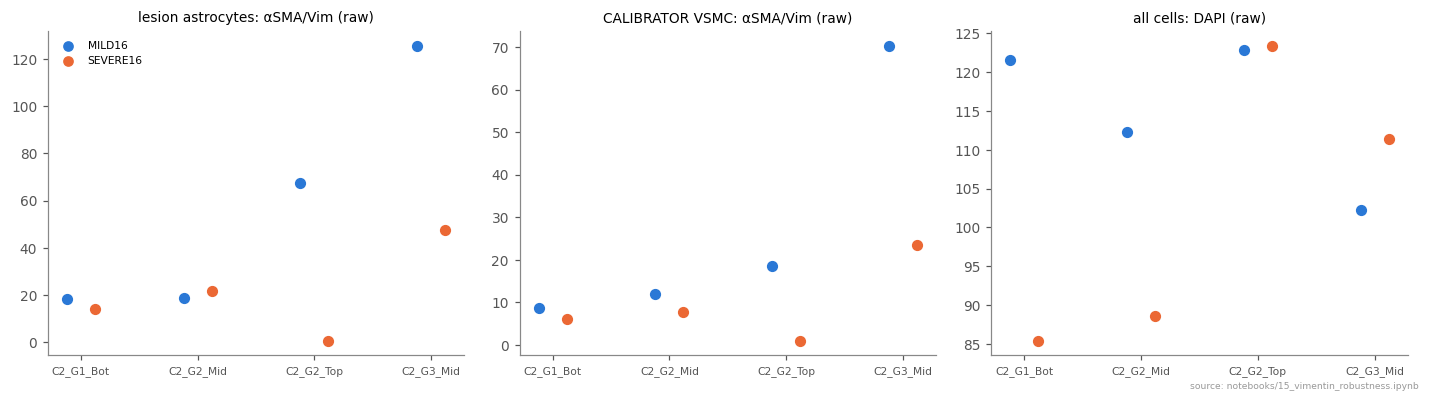

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, c, lab in zip(axs, ["lesion_astro_raw", "vsmc_raw", "dapi_raw_all"],
                      ["lesion astrocytes: αSMA/Vim (raw)", "CALIBRATOR VSMC: αSMA/Vim (raw)", "all cells: DAPI (raw)"]):
    for i, sec in enumerate(shared):
        d = same[same.image == sec]
        for _, r in d.iterrows():
            ax.scatter(i + (0.12 if r.stage == "SEVERE16" else -0.12), r[c], s=40,
                       color=COL[1] if r.stage == "SEVERE16" else COL[0])
    ax.set_xticks(range(len(shared)), [s.replace("run5_", "").replace("_0088858", "").replace("_0088870", "")
                                       for s in shared], fontsize=7)
    ax.set_title(lab, fontsize=9)
axs[0].scatter([], [], color=COL[0], label="MILD16"); axs[0].scatter([], [], color=COL[1], label="SEVERE16")
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "same_image_raw", OUT, SRC)

## Focus / sharpness per piece
Variance of the Laplacian of DAPI (level 1, 0.43 µm/px) within each piece: a standard focus measure. If the severe
pieces were blurrier, fine vimentin processes could look dimmer.

In [7]:
bundles = find_bundles(data.load_config())
want = animals.index[np.logical_or.reduce([f(animals) | s(animals) for f, s in CONTRASTS.values()])]
pcs = obs[obs.sample_name.isin(want)].groupby("meta_sample_id", observed=True).agg(
    sec=("sample_id", "first"), animal=("sample_name", "first"), x0=("x_centroid", "min"), x1=("x_centroid", "max"),
    y0=("y_centroid", "min"), y1=("y_centroid", "max"), n=("sample_id", "size"))
pcs = pcs[pcs.n >= 500]
sharp = {}
for sec, g in pcs.groupby("sec"):
    im = XeniumBundle(bundles[str(sec)]).read_level("dapi", 1).astype(np.float32)
    f = PX * 2
    for pc, r in g.iterrows():
        sub = im[int(r.y0 / f):int(r.y1 / f), int(r.x0 / f):int(r.x1 / f)]
        lap = ndi.laplace(ndi.gaussian_filter(sub, 1))
        sharp[pc] = lap[sub > np.percentile(sub, 60)].var() / max(sub[sub > np.percentile(sub, 60)].mean(), 1) ** 2
pcs["sharpness"] = pd.Series(sharp)
an_sharp = pcs.groupby("animal").sharpness.median()
add("piece sharpness (DAPI Laplacian; NOT vimentin)", an_sharp)
lesv = per_animal(fa[AST & fa.les], "smavim_z")
both = pd.concat([lesv.rename("lesion astro vimentin"), an_sharp.rename("sharpness")], axis=1).dropna()
print(f"ρ(lesion astro vimentin, piece sharpness) over {len(both)} animals: "
      f"{spearmanr(both.iloc[:, 0], both.iloc[:, 1]).statistic:+.2f}")
pd.DataFrame(tests["piece sharpness (DAPI Laplacian; NOT vimentin)"], index=["diff", "n milder", "n severe", "p"]).T.round(3)

/tmp/ipykernel_16429/928749793.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sec, g in pcs.groupby("sec"):


ρ(lesion astro vimentin, piece sharpness) over 32 animals: -0.23


/tmp/ipykernel_16429/928749793.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  an_sharp = pcs.groupby("animal").sharpness.median()


,diff,n milder,n severe,p
MILD16 vs SEVERE16,0.029,3.0,3.0,0.700
MILD30 vs SEVERE30,-0.132,5.0,2.0,0.095
MONOPHASIC vs REMISSION1,-0.008,4.0,5.0,0.556
chronic vs RR PEAK1,0.047,6.0,4.0,0.914


## Per image and per run
The within-animal contrast (lesion − non-lesion astrocytes), contrast by contrast, split by run: does each run
point the same way on its own?

In [8]:
lwr = lw.rename("lesion−non-lesion").to_frame().join(animals)
tab = []
for name, (fm, fs) in CONTRASTS.items():
    for run, g in lwr.groupby("run"):
        a_, b_ = g[fm(g)]["lesion−non-lesion"].dropna(), g[fs(g)]["lesion−non-lesion"].dropna()
        if len(a_) and len(b_):
            tab.append(dict(contrast=name, run=run, milder=a_.median(), severe=b_.median(), n=f"{len(a_)}+{len(b_)}"))
pd.DataFrame(tab).round(2)

,contrast,run,milder,severe,n
0,MILD16 vs SEVERE16,run5,2.07,0.97,3+3
1,MONOPHASIC vs REMISSION1,run2,4.62,1.85,2+2
2,MONOPHASIC vs REMISSION1,run3,4.17,0.82,2+1


## Summary
Each row of the forest plot is one technical test. The effect is robust if the four contrasts stay positive under
the vimentin tests, while the calibrator (VSMC), the control channels and the negative-control cell types stay near
zero.

In [9]:
summ = res.assign(positive=res["diff"] > 0).groupby("test", sort=False).agg(
    contrasts_positive=("positive", "sum"), contrasts=("positive", "size"), median_diff=("diff", "median"))
summ.round(2)

,contrasts_positive,contrasts,median_diff
test,,,
"baseline: lesion astrocytes, vimentin z",4,4,1.04
within animal: lesion − non-lesion astrocytes,4,4,1.09
control channel DAPI: lesion − non-lesion astrocytes,1,4,-0.10
control channel 18S rRNA: lesion − non-lesion astrocytes,3,4,0.14
control channel ATP1A1/CD45/E-Cad: lesion − non-lesion astrocytes,2,4,0.04
astrocytes > 20 µm from any vessel cell,4,4,1.01
"white matter, > 50 µm from tissue edge",4,4,1.99
reactive astrocytes (Reactive_AST) only,4,4,1.12
within state S0,4,4,0.64


## Where in the lesion? Containment ring vs resolution phase
Signed distance of every cell to the lesion edge within its piece: **positive = depth inside the lesion**
(distance to the nearest non-lesion cell), negative = distance outside (to the nearest lesion cell). Cells in
unscored regions (DRG, vasculature, central canal) are left out.

- **Containment ring:** vimentin peaks around the edge and is lower in the lesion core.
- **Resolution phase:** vimentin is flat across the lesion or highest in the core.

Readouts: astrocyte vimentin (cell, z within image) and tissue vimentin (10 µm territory around every cell, z
within image; many more cells).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/15_vimentin_robustness/vimentin_edge_profiles.png')

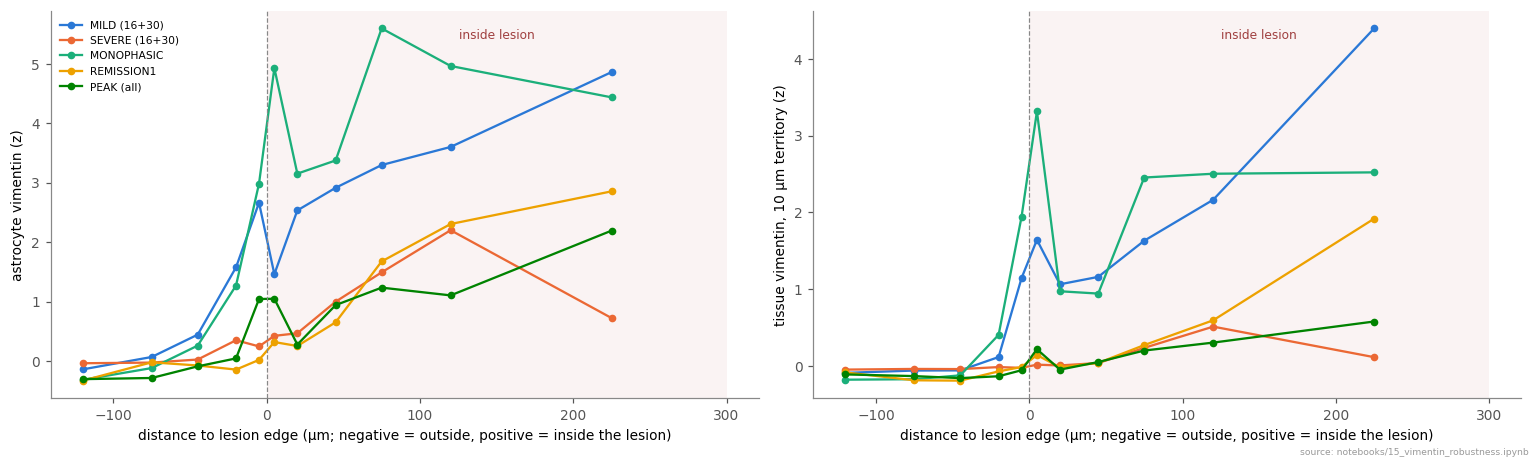

In [10]:
fa["terr_vim_z"] = zimg(fa.smavim_terr_mean, fa.section_id)
sd = pd.Series(np.nan, index=fa.index)
sc_obs = obs[obs.lesion_state != "not scored"]
for pc, g in sc_obs.groupby("meta_sample_id", observed=True):
    L = g[g.lesion_state.str.startswith("S")]
    N = g[g.lesion_state == "no lesion"]
    if len(L) < 50 or len(N) < 50:
        continue
    f = fa.index.intersection(g.index)
    xy = fa.loc[f, ["x_centroid", "y_centroid"]].to_numpy()
    inside = fa.loc[f, "les"].to_numpy()
    dN = cKDTree(N[["x_centroid", "y_centroid"]].to_numpy()).query(xy)[0]
    dL = cKDTree(L[["x_centroid", "y_centroid"]].to_numpy()).query(xy)[0]
    sd[f] = np.where(inside, dN, -dL)
fa["edge_dist_um"] = sd
BINS = [-150, -90, -60, -30, -10, 0, 10, 30, 60, 90, 150, 300]
fa["edge_bin"] = pd.cut(fa.edge_dist_um, BINS)

GROUPS = {
    "MILD (16+30)": fa.stage.isin(["MILD16", "MILD30"]), "SEVERE (16+30)": fa.stage.isin(["SEVERE16", "SEVERE30"]),
    "MONOPHASIC": fa.stage == "MONOPHASIC", "REMISSION1": fa.stage == "REMISSION1",
    "PEAK (all)": fa.stage.isin(["PEAK1", "PEAK2", "PEAK2_MILD", "PEAK3"]),
}
GCOL = {"MILD (16+30)": COL[0], "SEVERE (16+30)": COL[1], "MONOPHASIC": COL[2], "REMISSION1": COL[3],
        "PEAK (all)": COL[5]}


def profile(cells, value):
    """median over animals of the per-animal median per edge bin"""
    pa_ = cells.groupby(["sample_name", "edge_bin"], observed=True)[value].agg(["median", "count"])
    pa_ = pa_[pa_["count"] >= 15]["median"].unstack()
    return pa_.median(), pa_.notna().sum()


fig, axs = plt.subplots(1, 2, figsize=(14, 4.2), sharex=True)
mids = [(a + b) / 2 for a, b in zip(BINS[:-1], BINS[1:])]
for ax, (lab, cells, val) in zip(axs, [("astrocyte vimentin (z)", fa[AST], "smavim_z"),
                                       ("tissue vimentin, 10 µm territory (z)", fa, "terr_vim_z")]):
    for gname, m in GROUPS.items():
        med, n = profile(cells[m.reindex(cells.index)], val)
        med = med.reindex(fa.edge_bin.cat.categories)
        ax.plot(mids, med.values, marker="o", ms=4, color=GCOL[gname], label=gname)
    ax.axvline(0, color="#888888", lw=0.8, ls="--")
    ax.axvspan(0, 300, color="#f4e3e3", alpha=0.4, lw=0)
    ax.set(xlabel="distance to lesion edge (µm; negative = outside, positive = inside the lesion)", ylabel=lab)
    ax.text(150, ax.get_ylim()[1] * 0.92, "inside lesion", ha="center", fontsize=8, color="#a04040")
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "vimentin_edge_profiles", OUT, SRC)

**Ring index per animal**: median vimentin in the edge zone (−30 to +30 µm) minus the lesion core (> 60 µm inside).
> 0 = concentrated at the edge (ring); < 0 = highest in the core.

In [11]:
def ring_index(cells, value):
    e = cells[(cells.edge_dist_um > -30) & (cells.edge_dist_um <= 30)].groupby("sample_name", observed=True)[value]
    c = cells[cells.edge_dist_um > 60].groupby("sample_name", observed=True)[value]
    ok = (e.count() >= 20) & (c.count() >= 20)
    return (e.median() - c.median()).where(ok)


ri = pd.DataFrame({"ring index, astrocyte vimentin": ring_index(fa[AST], "smavim_z"),
                   "ring index, tissue vimentin": ring_index(fa, "terr_vim_z"),
                   "edge-zone astrocyte vimentin": fa[AST & (fa.edge_dist_um.abs() <= 30)].groupby("sample_name")
                   .smavim_z.median(),
                   "core astrocyte vimentin": fa[AST & (fa.edge_dist_um > 60)].groupby("sample_name").smavim_z.median()
                   }).join(animals)
ri.to_csv(OUT / "ring_index_per_animal.csv")
gl = pd.Series("other", index=ri.index)
for gname, m in GROUPS.items():
    gl[ri.index.isin(fa[m].sample_name.unique())] = gname
ri["group"] = gl
ri.groupby("group")[["ring index, astrocyte vimentin", "ring index, tissue vimentin", "edge-zone astrocyte vimentin",
                     "core astrocyte vimentin"]].agg(["median", "count"]).round(2)

/tmp/ipykernel_16429/2024845349.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "edge-zone astrocyte vimentin": fa[AST & (fa.edge_dist_um.abs() <= 30)].groupby("sample_name")
/tmp/ipykernel_16429/2024845349.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "core astrocyte vimentin": fa[AST & (fa.edge_dist_um > 60)].groupby("sample_name").smavim_z.median()


ring index, astrocyte vimentin        \
                                       median count   
group                                                 
MILD (16+30)                            -1.96     8   
MONOPHASIC                              -2.72     4   
PEAK (all)                              -1.04    19   
REMISSION1                              -1.62     5   
SEVERE (16+30)                          -1.57     5   
other                                   -0.82    13   

               ring index, tissue vimentin       edge-zone astrocyte vimentin  \
                                    median count                       median   
group                                                                           
MILD (16+30)                         -1.06     8                         2.41   
MONOPHASIC                           -1.92     4                         2.42   
PEAK (all)                           -0.60    19                         0.25   
REMISSION1                           -0.57     5                        -0.01   
SEVERE (16+30)                       -0.30     5                         0.41   
other                                -0.27    14                         0.67   

                     core astrocyte vimentin        
               count                  median count  
group                                               
MILD (16+30)       8                    3.27     8  
MONOPHASIC         4                    6.12     4  
PEAK (all)        19                    1.55    19  
REMISSION1         5                    1.89     5  
SEVERE (16+30)     5                    1.98     5  
other             24                    1.57    22

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/15_vimentin_robustness/ring_index.png')

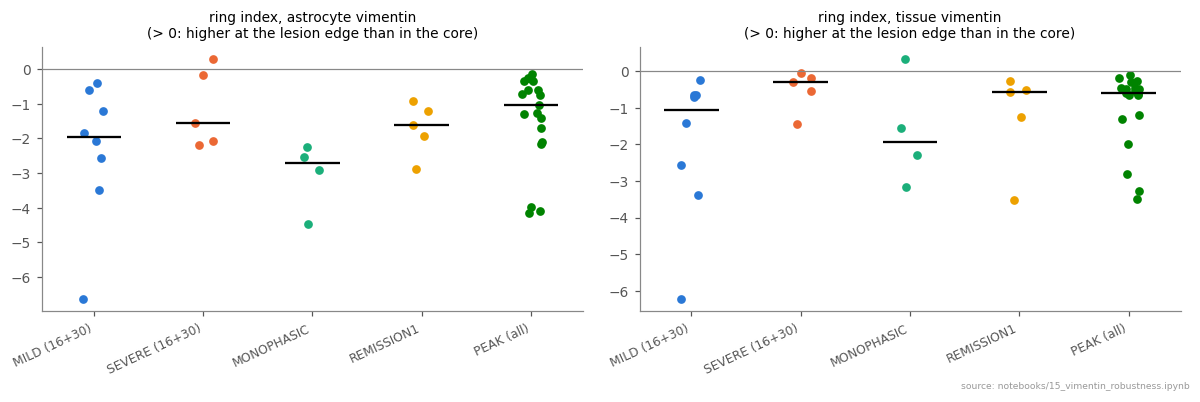

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, c in zip(axs, ["ring index, astrocyte vimentin", "ring index, tissue vimentin"]):
    for k, gname in enumerate(GROUPS):
        v = ri[ri.group == gname][c].dropna()
        ax.scatter(np.full(len(v), k) + np.random.default_rng(k).uniform(-0.1, 0.1, len(v)), v, s=22, color=GCOL[gname])
        ax.hlines(v.median(), k - 0.25, k + 0.25, color="black", lw=1.5)
    ax.axhline(0, color="#888888", lw=0.8)
    ax.set_xticks(range(len(GROUPS)), list(GROUPS), rotation=25, ha="right", fontsize=8)
    ax.set_title(c + "\n(> 0: higher at the lesion edge than in the core)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "ring_index", OUT, SRC)

## Could it be αSMA instead of vimentin?
The channel stains αSMA and vimentin together. Astrocytes don't normally make αSMA; vascular smooth muscle,
pericytes and myofibroblasts (activated fibroblasts in fibrotic lesions) do. Three tests:

1. **Exclude astrocytes near any αSMA-type cell**: no VSMC, endothelial cell or fibroblast (incl. EAE-associated)
   within 20 µm.
2. **RNA spill-over check**: smooth-muscle / contractile transcripts (*Myh11, Tagln, Cnn1, Des, Mylk, Smtn*; *Acta2*
   is not on the panel), pericyte (*Pdgfrb, Kcnj8*) and fibroblast (*Postn, Col1a1*) transcripts in lesion astrocytes.
   If milder animals' lesion astrocytes carried more of these, their signal could come from neighbouring αSMA cells.
3. **Does lesion astrocyte signal follow nearby fibroblast density?** If it were myofibroblast αSMA, it should.

In [13]:
SMA_SRC = obs.Anno_L1_curated.isin(["VSMC", "Endothelial", "Fibroblast"])
nd = pd.Series(np.inf, index=fa.index)
fib_n = pd.Series(0, index=fa.index, dtype=float)
for pc, g in fa[AST].groupby("meta_sample_id", observed=True):
    src = obs[(obs.meta_sample_id == pc) & SMA_SRC]
    if len(src):
        t = cKDTree(src[["x_centroid", "y_centroid"]].to_numpy())
        xy = g[["x_centroid", "y_centroid"]].to_numpy()
        nd[g.index] = t.query(xy)[0]
        fib_n[g.index] = [len(x) for x in t.query_ball_point(xy, 50)]
fa["sma_src_um"], fa["sma_src_n50"] = nd, fib_n
add("αSMA test: astrocytes > 20 µm from any VSMC/endothelial/fibroblast",
    per_animal(fa[AST & fa.les & (fa.sma_src_um > 20)], "smavim_z"))
print("lesion astrocytes kept after excluding αSMA-cell neighbours:",
      f"{(fa[AST & fa.les].sma_src_um > 20).mean():.0%}")

lesion astrocytes kept after excluding αSMA-cell neighbours: 60%


In [14]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
SMG = {"smooth muscle / contractile": ["Myh11", "Tagln", "Cnn1", "Des", "Mylk", "Smtn"],
       "pericyte": ["Pdgfrb", "Kcnj8"], "fibroblast": ["Postn", "Col1a1"],
       "astrocyte reactivity (reference)": ["Gfap", "Serpina3n", "Cd44", "Nes"]}
genes = [g for v in SMG.values() for g in v]
la = fa[AST & fa.les].index
X = a[la.to_numpy(), genes].to_memory().X
X = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
a.file.close()
ex = pd.DataFrame(X, index=la, columns=genes)
prog_ = pd.DataFrame({k: ex[v].mean(1) for k, v in SMG.items()})
rna = prog_.groupby(fa.loc[la, "sample_name"]).mean()
for k in SMG:
    add(f"RNA in lesion astrocytes: {k} (log-norm; NOT protein)", rna[k])
rna.join(animals).groupby("stage")[list(SMG)].median().reindex(
    ["MILD16", "SEVERE16", "MILD30", "SEVERE30", "MONOPHASIC", "REMISSION1", "PEAK1"]).round(3)

/tmp/ipykernel_16429/1724090076.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rna = prog_.groupby(fa.loc[la, "sample_name"]).mean()


,smooth muscle / contractile,pericyte,fibroblast,astrocyte reactivity (reference)
stage,,,,
MILD16,0.145,0.132,0.066,1.595
SEVERE16,0.120,0.107,0.048,1.559
MILD30,0.137,0.122,0.078,1.685
SEVERE30,0.143,0.137,0.065,1.648
MONOPHASIC,0.149,0.107,0.048,1.572
REMISSION1,0.116,0.093,0.039,1.376
PEAK1,0.151,0.100,0.035,1.507


In [15]:
d = fa[AST & fa.les]
rho_cell = spearmanr(d.sma_src_n50, d.smavim_z, nan_policy="omit").statistic
an_fib = d.groupby("sample_name").sma_src_n50.median()
add("αSMA-type cells within 50 µm of lesion astrocytes (count; NOT vimentin)", an_fib)
print(f"cell level: ρ(lesion astrocyte vimentin, αSMA-type cells within 50 µm) = {rho_cell:+.2f}")
pd.DataFrame({k: tests[k] for k in list(tests)[-7:]}, index=["diff", "n milder", "n severe", "p"]).T.round(3)

cell level: ρ(lesion astrocyte vimentin, αSMA-type cells within 50 µm) = +0.18


/tmp/ipykernel_16429/479887773.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  an_fib = d.groupby("sample_name").sma_src_n50.median()


,diff,n milder,n severe,p
piece sharpness (DAPI Laplacian; NOT vimentin),NaN,NaN,NaN,NaN
αSMA test: astrocytes > 20 µm from any VSMC/endothelial/fibroblast,NaN,NaN,NaN,NaN
RNA in lesion astrocytes: smooth muscle / contractile (log-norm; NOT protein),NaN,NaN,NaN,NaN
RNA in lesion astrocytes: pericyte (log-norm; NOT protein),NaN,NaN,NaN,NaN
RNA in lesion astrocytes: fibroblast (log-norm; NOT protein),NaN,NaN,NaN,NaN
RNA in lesion astrocytes: astrocyte reactivity (reference) (log-norm; NOT protein),NaN,NaN,NaN,NaN
αSMA-type cells within 50 µm of lesion astrocytes (count; NOT vimentin),NaN,NaN,NaN,NaN


,contrasts_positive,contrasts,median_diff
test,,,
"baseline: lesion astrocytes, vimentin z",4,4,1.04
within animal: lesion − non-lesion astrocytes,4,4,1.09
control channel DAPI: lesion − non-lesion astrocytes,1,4,-0.10
control channel 18S rRNA: lesion − non-lesion astrocytes,3,4,0.14
control channel ATP1A1/CD45/E-Cad: lesion − non-lesion astrocytes,2,4,0.04
astrocytes > 20 µm from any vessel cell,4,4,1.01
"white matter, > 50 µm from tissue edge",4,4,1.99
reactive astrocytes (Reactive_AST) only,4,4,1.12
within state S0,4,4,0.64


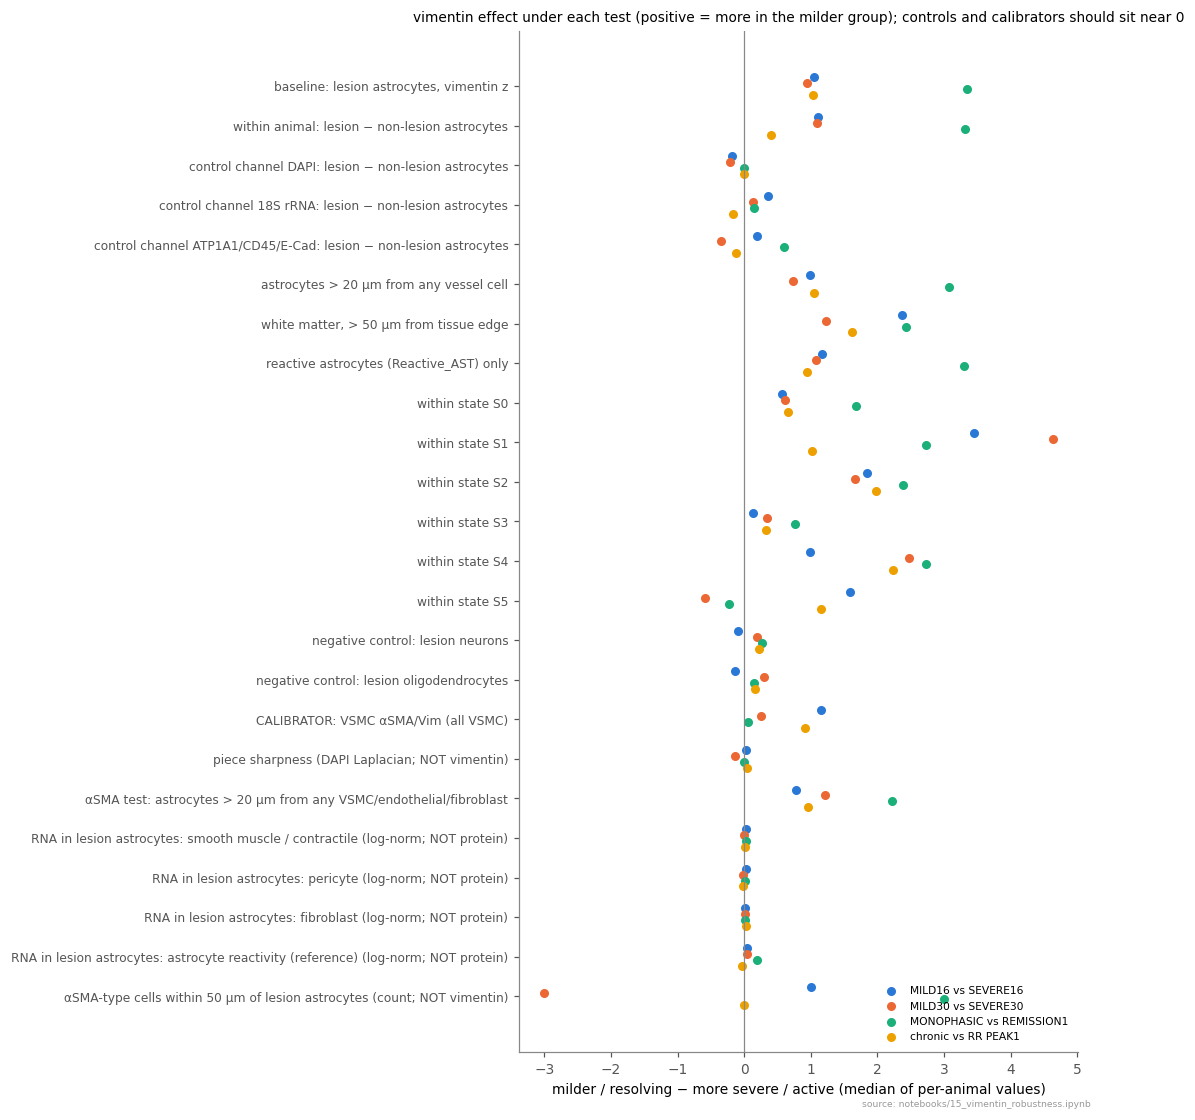

In [16]:
# refresh the summary and forest plot with all tests
rows = []
for tname, dd in tests.items():
    for cname, (diff, na, nb, p) in dd.items():
        rows.append(dict(test=tname, contrast=cname, diff=diff, n_milder=na, n_severe=nb, p=p))
res = pd.DataFrame(rows)
res.to_csv(OUT / "robustness_tests.csv", index=False)
piv = res.pivot(index="test", columns="contrast", values="diff").reindex(list(tests))
fig, ax = plt.subplots(figsize=(10, 0.36 * len(piv) + 1.5))
for j, c in enumerate(piv.columns):
    ax.scatter(piv[c], np.arange(len(piv)) + (j - 1.5) * 0.15, s=24, color=COL[j], label=c)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(range(len(piv)), piv.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("milder / resolving − more severe / active (median of per-animal values)")
ax.legend(fontsize=7, loc="lower right")
ax.set_title("vimentin effect under each test (positive = more in the milder group); "
             "controls and calibrators should sit near 0", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "robustness_forest", OUT, SRC)
res.assign(positive=res["diff"] > 0).groupby("test", sort=False).agg(
    contrasts_positive=("positive", "sum"), contrasts=("positive", "size"), median_diff=("diff", "median")).round(2)

## Findings

> **Finding — the vimentin effect is not a technical artefact and not αSMA.** Every vimentin test keeps the
> direction in all four contrasts (milder − more severe, z): within-animal lesion − non-lesion astrocytes +1.10 /
> +1.09 / +3.31 / +0.40; astrocytes > 20 µm from any VSMC/endothelial/fibroblast cell +0.78 / +1.21 / +2.22 / +0.96;
> deep white matter +2.36 / +1.24 / +2.43 / +1.61; reactive astrocytes only +1.17 / +1.07 / +3.30 / +0.94; and
> within lesion states S1, S2, S4. Controls stay near zero: DAPI −0.21…0.00, lesion neurons/oligodendrocytes ~0–0.3,
> piece sharpness ~0, and smooth-muscle / pericyte / fibroblast transcripts in the lesion astrocytes ~0 (no sign
> of αSMA-cell contamination). **Caveat from the calibrator:** VSMC αSMA/Vim is also higher in the milder group for
> MILD16 vs SEVERE16 (+1.16) and chronic vs RR PEAK1 (+0.91), so part of those two raw differences may be piece-level
> channel brightness. The within-animal contrast removes it (+1.10 for MILD16 vs SEVERE16; chronic vs RR shrinks to
> +0.40, the weakest contrast). MILD30 vs SEVERE30 (calibrator +0.25) and MONOPHASIC vs REMISSION1 (+0.06) are clean.
>
> **Superseded (notebook 16): no ring.** With proper lesion-region outlines there is no edge peak; the profile below
> came from a cell-based edge distance where "just inside" meant isolated lesion cells in healthy tissue. Kept for
> the record:
>
> ~~A vimentin ring at the lesion edge in milder and never-relapsing animals.~~ Edge profiles: MILD and
> MONOPHASIC animals show a sharp vimentin peak in the first ~10 µm inside the lesion edge (tissue vimentin z ≈ 1.6 and
> 3.3; ~0 just outside), a dip at 20–45 µm, and high vimentin again in the lesion core. SEVERE, REMISSION1 and PEAK
> animals have no edge peak and less core vimentin. So milder outcomes come with both a containment ring and
> vimentin-rich lesion interiors. The edge-minus-core "ring index" misses this (the core is high too); notebook 16
> uses an edge-spike measure and tests whether better-bordered lesions leak fewer immune cells.